In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

In [6]:
import pandas as pd

df = pd.read_csv("../data/OnlineRetail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [9]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df = df.dropna(subset=['CustomerID'])

In [12]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [13]:
print(df.duplicated().sum())

df = df.drop_duplicates()

5225


In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              int64
Country                   str
dtype: object

In [16]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [17]:
df = df[df['Quantity'] > 0]

In [18]:
df = df[df['UnitPrice'] > 0]

In [19]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [20]:
df['InvoiceNo'].nunique()

18532

In [21]:
df['CustomerID'].nunique()

4338

In [22]:
df['Revenue'].sum()

np.float64(8887208.894000001)

In [23]:
df['Revenue'].mean()

np.float64(22.631499735161402)

In [24]:
first_purchase = df.groupby('CustomerID')['InvoiceDate'].min()

In [25]:
df = df.merge(
    first_purchase.rename('FirstPurchaseDate'),
    on='CustomerID'
)

In [26]:
df['CohortMonth'] = df['FirstPurchaseDate'].dt.to_period('M')

In [27]:
df['TransactionMonth'] = df['InvoiceDate'].dt.to_period('M')

In [30]:
df.to_csv("../outputs/cleaned_data.csv", index=False)

WEEK 2


In [31]:
invoice_year = df['InvoiceDate'].dt.year
invoice_month = df['InvoiceDate'].dt.month

cohort_year = df['FirstPurchaseDate'].dt.year
cohort_month = df['FirstPurchaseDate'].dt.month

In [32]:
year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

df['CohortIndex'] = year_diff * 12 + month_diff + 1

In [33]:
cohort_data = df.groupby(
    ['CohortMonth','CohortIndex']
)['CustomerID'].nunique().reset_index()

In [34]:
cohort_data.head()

,CohortMonth,CohortIndex,CustomerID
0,2010-12,1,885
1,2010-12,2,324
2,2010-12,3,286
3,2010-12,4,340
4,2010-12,5,321


In [35]:
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

In [36]:
cohort_size = cohort_counts.iloc[:,0]

In [37]:
retention = cohort_counts.divide(cohort_size, axis=0)

In [44]:
retention = (retention * 100).round(2)

In [45]:
cohort_counts.to_csv("../outputs/cohort_matrix.csv")

retention.to_csv("../outputs/retention_matrix.csv")

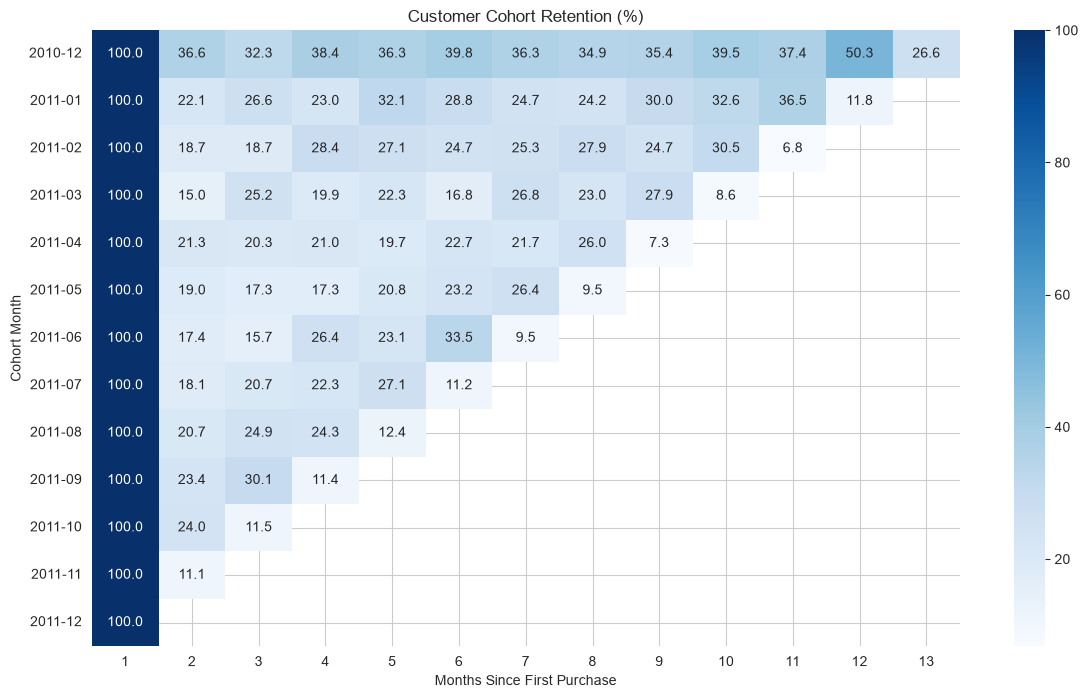

In [46]:
plt.figure(figsize=(14,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Customer Cohort Retention (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

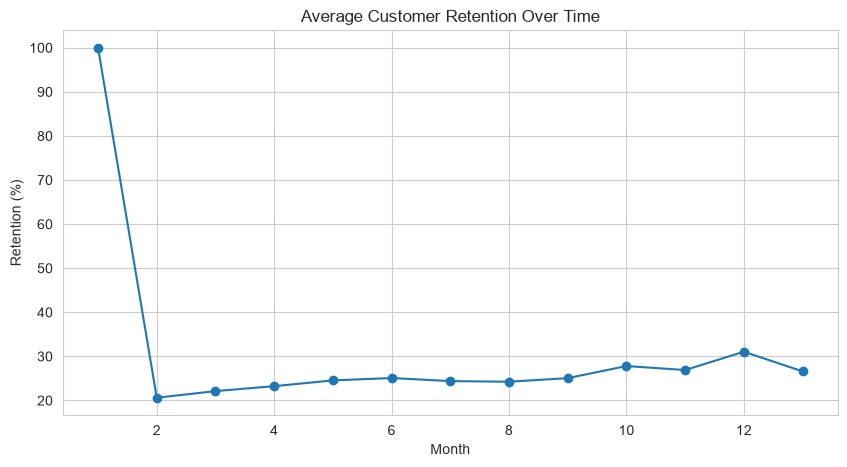

In [47]:
average_retention = retention.mean()

plt.figure(figsize=(10,5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker='o'
)

plt.title("Average Customer Retention Over Time")
plt.xlabel("Month")
plt.ylabel("Retention (%)")

plt.grid(True)

plt.show()

In [48]:
customer_summary = (
    df.groupby("CustomerID")
      .agg(
          TotalOrders=("InvoiceNo", "nunique"),
          TotalRevenue=("Revenue", "sum")
      )
)

customer_summary.head()

,TotalOrders,TotalRevenue
CustomerID,,
12346,1,77183.60
12347,7,4310.00
12348,4,1797.24
12349,1,1757.55
12350,1,334.40


In [50]:
customer_summary["AverageOrderValue"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["TotalOrders"]
)

customer_summary.head()

,TotalOrders,TotalRevenue,AverageOrderValue
CustomerID,,,
12346,1,77183.60,77183.600000
12347,7,4310.00,615.714286
12348,4,1797.24,449.310000
12349,1,1757.55,1757.550000
12350,1,334.40,334.400000


In [51]:
purchase_frequency = (
    df["InvoiceNo"].nunique() /
    df["CustomerID"].nunique()
)

print("Overall Purchase Frequency:", purchase_frequency)

Overall Purchase Frequency: 4.272014753342554


In [61]:
customer_summary["PurchaseFrequency"] = purchase_frequency

customer_summary.head()

,TotalOrders,TotalRevenue,AverageOrderValue,LifetimeMonths_x,LifetimeMonths_y,LifetimeMonths,PurchaseFrequency
CustomerID,,,,,,,
12346,1,77183.60,77183.600000,0.00,0.00,0.00,4.272015
12347,7,4310.00,615.714286,12.17,12.17,12.17,4.272015
12348,4,1797.24,449.310000,9.40,9.40,9.40,4.272015
12349,1,1757.55,1757.550000,0.00,0.00,0.00,4.272015
12350,1,334.40,334.400000,0.00,0.00,0.00,4.272015


In [52]:
customer_lifetime = (
    df.groupby("CustomerID")["InvoiceDate"]
      .agg(["min", "max"])
)

customer_lifetime.head()

,min,max
CustomerID,,
12346,2011-01-18 10:01:00,2011-01-18 10:01:00
12347,2010-12-07 14:57:00,2011-12-07 15:52:00
12348,2010-12-16 19:09:00,2011-09-25 13:13:00
12349,2011-11-21 09:51:00,2011-11-21 09:51:00
12350,2011-02-02 16:01:00,2011-02-02 16:01:00


In [53]:
customer_lifetime["LifetimeDays"] = (
    customer_lifetime["max"] -
    customer_lifetime["min"]
).dt.days

customer_lifetime.head()

,min,max,LifetimeDays
CustomerID,,,
12346,2011-01-18 10:01:00,2011-01-18 10:01:00,0
12347,2010-12-07 14:57:00,2011-12-07 15:52:00,365
12348,2010-12-16 19:09:00,2011-09-25 13:13:00,282
12349,2011-11-21 09:51:00,2011-11-21 09:51:00,0
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,0


In [54]:
customer_lifetime["LifetimeMonths"] = (
    customer_lifetime["LifetimeDays"] / 30
).round(2)

customer_lifetime.head()

,min,max,LifetimeDays,LifetimeMonths
CustomerID,,,,
12346,2011-01-18 10:01:00,2011-01-18 10:01:00,0,0.00
12347,2010-12-07 14:57:00,2011-12-07 15:52:00,365,12.17
12348,2010-12-16 19:09:00,2011-09-25 13:13:00,282,9.40
12349,2011-11-21 09:51:00,2011-11-21 09:51:00,0,0.00
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,0,0.00


In [64]:
customer_summary.columns.tolist()

['TotalOrders',
 'TotalRevenue',
 'AverageOrderValue',
 'LifetimeMonths_x',
 'LifetimeMonths_y',
 'LifetimeMonths',
 'PurchaseFrequency']

In [65]:
customer_summary[["LifetimeMonths"]].head()

,LifetimeMonths
CustomerID,
12346,0.00
12347,12.17
12348,9.40
12349,0.00
12350,0.00


In [66]:
customer_summary["CLTV"] = (
    customer_summary["AverageOrderValue"]
    * customer_summary["PurchaseFrequency"]
    * customer_summary["LifetimeMonths"]
)

customer_summary.head()

,TotalOrders,TotalRevenue,AverageOrderValue,LifetimeMonths_x,LifetimeMonths_y,LifetimeMonths,PurchaseFrequency,CLTV
CustomerID,,,,,,,,
12346,1,77183.60,77183.600000,0.00,0.00,0.00,4.272015,0.000000
12347,7,4310.00,615.714286,12.17,12.17,12.17,4.272015,32011.244036
12348,4,1797.24,449.310000,9.40,9.40,9.40,4.272015,18042.914119
12349,1,1757.55,1757.550000,0.00,0.00,0.00,4.272015,0.000000
12350,1,334.40,334.400000,0.00,0.00,0.00,4.272015,0.000000


In [67]:
customer_summary.isnull().sum()

TotalOrders          0
TotalRevenue         0
AverageOrderValue    0
LifetimeMonths_x     0
LifetimeMonths_y     0
LifetimeMonths       0
PurchaseFrequency    0
CLTV                 0
dtype: int64

In [69]:
customer_summary["CLTV"].describe()

count    4.338000e+03
mean     8.044899e+03
std      3.962487e+04
min      0.000000e+00
25%      0.000000e+00
50%      3.134648e+03
75%      1.048589e+04
max      2.447038e+06
Name: CLTV, dtype: float64

In [70]:
(customer_summary["CLTV"] == 0).sum()

np.int64(1555)

In [71]:
customer_summary[customer_summary["CLTV"] == 0].head()

,TotalOrders,TotalRevenue,AverageOrderValue,LifetimeMonths_x,LifetimeMonths_y,LifetimeMonths,PurchaseFrequency,CLTV
CustomerID,,,,,,,,
12346,1,77183.60,77183.60,0.0,0.0,0.0,4.272015,0.0
12349,1,1757.55,1757.55,0.0,0.0,0.0,4.272015,0.0
12350,1,334.40,334.40,0.0,0.0,0.0,4.272015,0.0
12353,1,89.00,89.00,0.0,0.0,0.0,4.272015,0.0
12354,1,1079.40,1079.40,0.0,0.0,0.0,4.272015,0.0


In [72]:
customer_summary["CustomerSegment"] = pd.cut(
    customer_summary["CLTV"],
    bins=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

customer_summary.head()

,TotalOrders,TotalRevenue,AverageOrderValue,LifetimeMonths_x,LifetimeMonths_y,LifetimeMonths,PurchaseFrequency,CLTV,CustomerSegment
CustomerID,,,,,,,,,
12346,1,77183.60,77183.600000,0.00,0.00,0.00,4.272015,0.000000,Low Value
12347,7,4310.00,615.714286,12.17,12.17,12.17,4.272015,32011.244036,Low Value
12348,4,1797.24,449.310000,9.40,9.40,9.40,4.272015,18042.914119,Low Value
12349,1,1757.55,1757.550000,0.00,0.00,0.00,4.272015,0.000000,Low Value
12350,1,334.40,334.400000,0.00,0.00,0.00,4.272015,0.000000,Low Value


In [73]:
customer_summary["LifetimeMonths"] = (
    customer_summary["LifetimeMonths"]
    .replace(0, 1)
)

In [74]:
customer_summary["CLTV"] = (
    customer_summary["AverageOrderValue"]
    * customer_summary["PurchaseFrequency"]
    * customer_summary["LifetimeMonths"]
)

In [75]:
customer_summary["CustomerSegment"] = pd.qcut(
    customer_summary["CLTV"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

In [76]:
customer_summary.head()

,TotalOrders,TotalRevenue,AverageOrderValue,LifetimeMonths_x,LifetimeMonths_y,LifetimeMonths,PurchaseFrequency,CLTV,CustomerSegment
CustomerID,,,,,,,,,
12346,1,77183.60,77183.600000,0.00,0.00,1.00,4.272015,329729.477916,High Value
12347,7,4310.00,615.714286,12.17,12.17,12.17,4.272015,32011.244036,High Value
12348,4,1797.24,449.310000,9.40,9.40,9.40,4.272015,18042.914119,High Value
12349,1,1757.55,1757.550000,0.00,0.00,1.00,4.272015,7508.279530,Medium Value
12350,1,334.40,334.400000,0.00,0.00,1.00,4.272015,1428.561734,Low Value


In [77]:
customer_summary["CustomerSegment"].value_counts()

CustomerSegment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64

In [78]:
customer_summary.to_csv(
    "../outputs/customer_cltv.csv",
    index=True
)

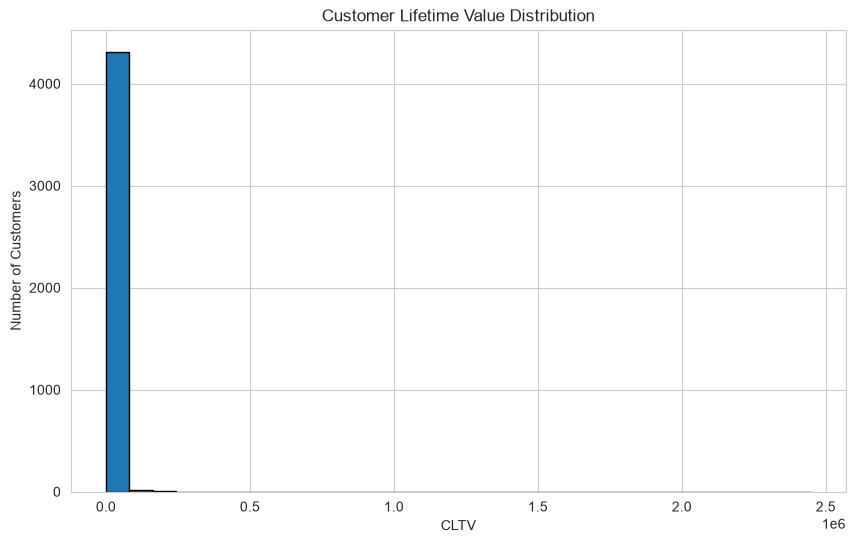

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    customer_summary["CLTV"],
    bins=30,
    edgecolor="black"
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLTV")
plt.ylabel("Number of Customers")

plt.show()

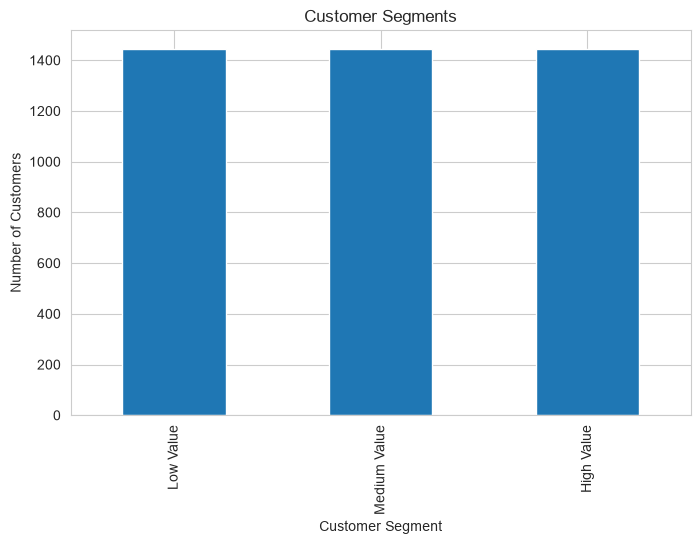

In [80]:
customer_summary["CustomerSegment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

In [81]:
customer_summary.sort_values(
    by="CLTV",
    ascending=False
).head(10)

,TotalOrders,TotalRevenue,AverageOrderValue,LifetimeMonths_x,LifetimeMonths_y,LifetimeMonths,PurchaseFrequency,CLTV,CustomerSegment
CustomerID,,,,,,,,,
16446,2,168472.50,84236.250000,6.80,6.80,6.80,4.272015,2.447038e+06,High Value
12346,1,77183.60,77183.600000,0.00,0.00,1.00,4.272015,3.297295e+05,High Value
12415,21,124914.53,5948.310952,10.43,10.43,10.43,4.272015,2.650396e+05,High Value
18102,60,259657.30,4327.621667,12.20,12.20,12.20,4.272015,2.255495e+05,High Value
17450,46,194390.79,4225.886739,11.97,11.97,11.97,4.272015,2.160950e+05,High Value
15749,3,44534.30,14844.766667,3.23,3.23,3.23,4.272015,2.048371e+05,High Value
14646,73,280206.02,3838.438630,11.77,11.77,11.77,4.272015,1.930029e+05,High Value
14088,13,50491.81,3883.985385,10.40,10.40,10.40,4.272015,1.725614e+05,High Value
12753,6,21429.39,3571.565000,11.30,11.30,11.30,4.272015,1.724129e+05,High Value


In [82]:
print("Average CLTV :", round(customer_summary["CLTV"].mean(), 2))
print("Highest CLTV :", round(customer_summary["CLTV"].max(), 2))
print("Lowest CLTV :", round(customer_summary["CLTV"].min(), 2))

Average CLTV : 8686.78
Highest CLTV : 2447037.82
Lowest CLTV : 2.67


In [83]:
customer_summary.groupby("CustomerSegment")["CLTV"].mean()

CustomerSegment
Low Value         848.745171
Medium Value     4063.653947
High Value      21147.934105
Name: CLTV, dtype: float64

In [84]:
print("===== BUSINESS INSIGHTS =====")

print(f"Total Customers: {customer_summary.shape[0]}")

print(f"Average Customer Lifetime Value: {customer_summary['CLTV'].mean():.2f}")

print("\nCustomer Segmentation:")

print(customer_summary["CustomerSegment"].value_counts())

print("\nTop 10 Customers by CLTV:")

print(customer_summary.sort_values("CLTV", ascending=False).head(10))

===== BUSINESS INSIGHTS =====
Total Customers: 4338
Average Customer Lifetime Value: 8686.78

Customer Segmentation:
CustomerSegment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64

Top 10 Customers by CLTV:
            TotalOrders  TotalRevenue  AverageOrderValue  LifetimeMonths_x  \
CustomerID                                                                   
16446                 2     168472.50       84236.250000              6.80   
12346                 1      77183.60       77183.600000              0.00   
12415                21     124914.53        5948.310952             10.43   
18102                60     259657.30        4327.621667             12.20   
17450                46     194390.79        4225.886739             11.97   
15749                 3      44534.30       14844.766667              3.23   
14646                73     280206.02        3838.438630             11.77   
14088                13      50491.81        3883

In [85]:
customer_summary.drop(
    columns=["LifetimeMonths_x", "LifetimeMonths_y"],
    inplace=True,
    errors="ignore"
)

In [86]:
customer_summary.columns

Index(['TotalOrders', 'TotalRevenue', 'AverageOrderValue', 'LifetimeMonths',
       'PurchaseFrequency', 'CLTV', 'CustomerSegment'],
      dtype='str')

# Week 3 Summary

- Calculated Average Order Value (AOV)
- Measured Purchase Frequency
- Computed Customer Lifetime
- Implemented Customer Lifetime Value (CLTV)
- Segmented customers into Low, Medium, and High Value groups
- Generated business insights from customer analytics

In [119]:
segment_revenue = customer_summary.groupby("CustomerSegment")["TotalRevenue"].sum()

segment_revenue

CustomerSegment
Low Value        398795.800
Medium Value    1250894.484
High Value      7237518.610
Name: TotalRevenue, dtype: float64

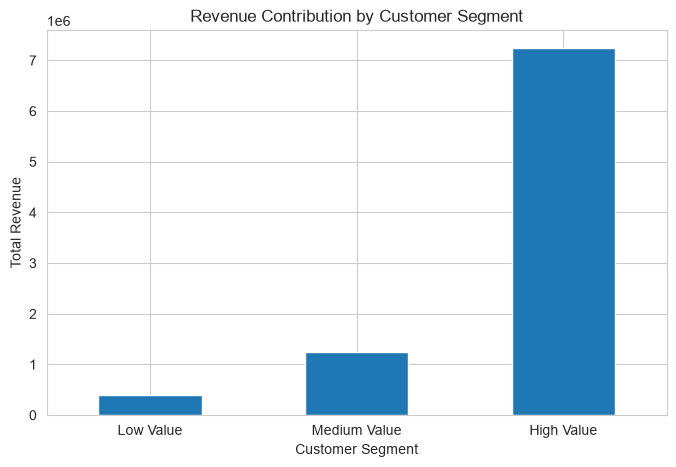

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.show()

In [121]:
segment_cltv = customer_summary.groupby("CustomerSegment")["CLTV"].mean()

segment_cltv

CustomerSegment
Low Value         848.745171
Medium Value     4063.653947
High Value      21147.934105
Name: CLTV, dtype: float64

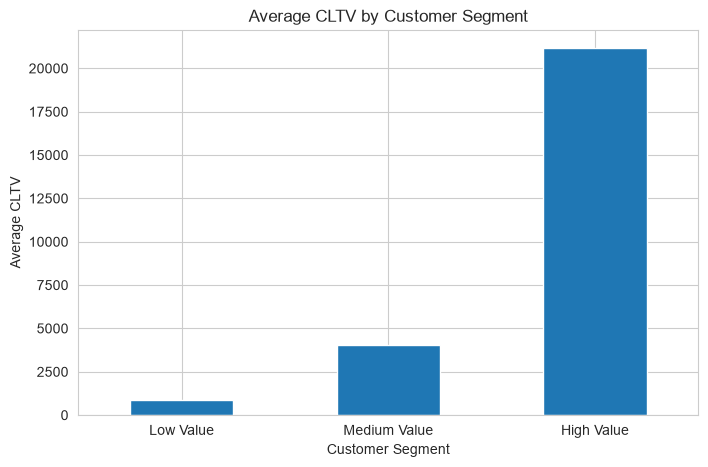

In [122]:
plt.figure(figsize=(8,5))

segment_cltv.plot(kind="bar")

plt.title("Average CLTV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average CLTV")

plt.xticks(rotation=0)

plt.show()

In [123]:
top_customers = customer_summary.sort_values(
    by="TotalRevenue",
    ascending=False
).head(10)

top_customers

,TotalOrders,TotalRevenue,AverageOrderValue,LifetimeMonths,PurchaseFrequency,CLTV,CustomerSegment
CustomerID,,,,,,,
14646,73,280206.02,3838.438630,11.77,4.272015,1.930029e+05,High Value
18102,60,259657.30,4327.621667,12.20,4.272015,2.255495e+05,High Value
17450,46,194390.79,4225.886739,11.97,4.272015,2.160950e+05,High Value
16446,2,168472.50,84236.250000,6.80,4.272015,2.447038e+06,High Value
14911,201,143711.17,714.980945,12.40,4.272015,3.787467e+04,High Value
12415,21,124914.53,5948.310952,10.43,4.272015,2.650396e+05,High Value
14156,55,117210.08,2131.092364,12.03,4.272015,1.095218e+05,High Value
17511,31,91062.38,2937.496129,12.33,4.272015,1.547295e+05,High Value
16029,63,80850.84,1283.346667,11.17,4.272015,6.123926e+04,High Value


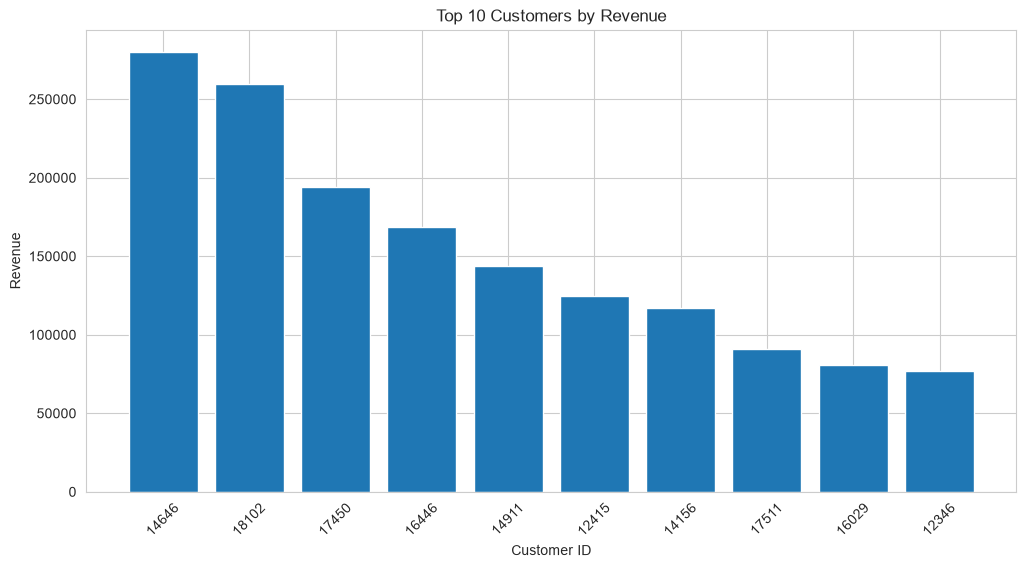

In [124]:
plt.figure(figsize=(12,6))

plt.bar(
    top_customers.index.astype(str),
    top_customers["TotalRevenue"]
)

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customer ID")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [125]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

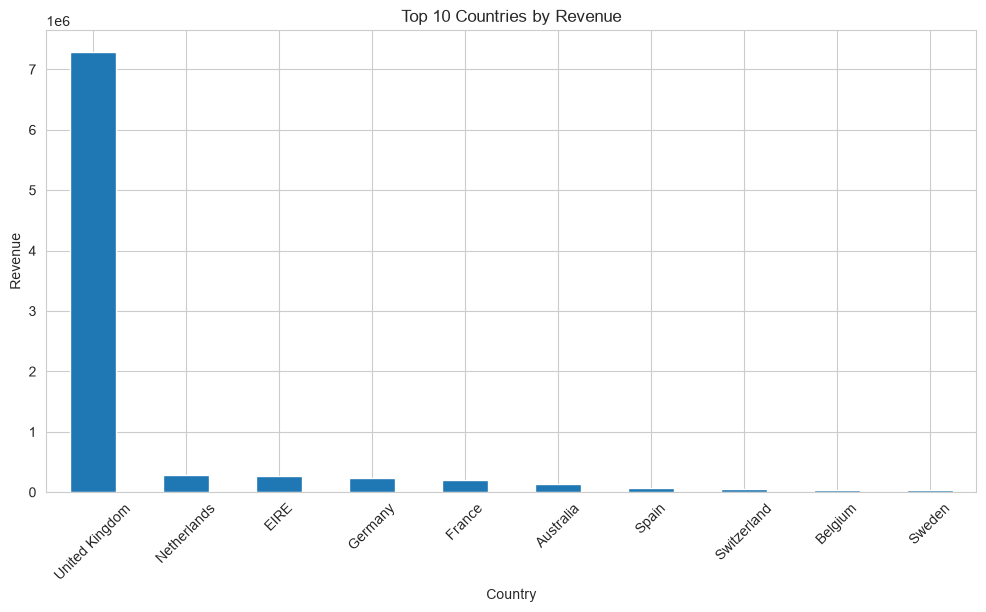

In [126]:
plt.figure(figsize=(12,6))

country_revenue.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [127]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

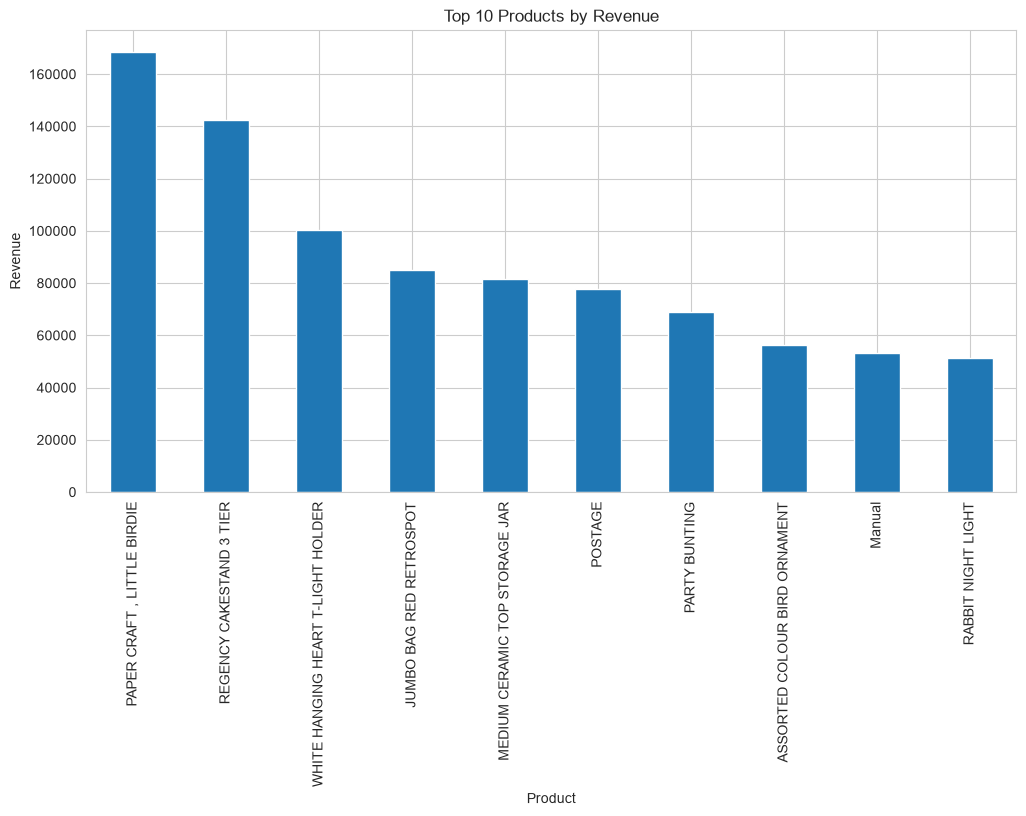

In [128]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

In [129]:
segment_summary = customer_summary.groupby(
    "CustomerSegment"
).agg(
    Customers=("CLTV","count"),
    AverageCLTV=("CLTV","mean"),
    AverageRevenue=("TotalRevenue","mean"),
    AverageOrders=("TotalOrders","mean")
)

segment_summary

,Customers,AverageCLTV,AverageRevenue,AverageOrders
CustomerSegment,,,,
Low Value,1446,848.745171,275.792393,1.412172
Medium Value,1446,4063.653947,865.072257,3.147994
High Value,1446,21147.934105,5005.199592,8.255878


In [130]:
segment_summary.to_csv(
    "../outputs/customer_segment_summary.csv"
)

In [131]:
print("="*50)
print("FINAL BUSINESS INSIGHTS")
print("="*50)

print(f"\nTotal Customers : {customer_summary.shape[0]}")

print(f"\nAverage CLTV : {customer_summary['CLTV'].mean():.2f}")

print("\nCustomer Segments")

print(customer_summary["CustomerSegment"].value_counts())

print("\nTop Revenue Country")

print(country_revenue.head())

print("\nTop Revenue Products")

print(top_products.head())

print("\nTop Customers")

print(
    customer_summary.sort_values(
        "CLTV",
        ascending=False
    ).head(10)
)

FINAL BUSINESS INSIGHTS

Total Customers : 4338

Average CLTV : 8686.78

Customer Segments
CustomerSegment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64

Top Revenue Country
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: Revenue, dtype: float64

Top Revenue Products
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
Name: Revenue, dtype: float64

Top Customers
            TotalOrders  TotalRevenue  AverageOrderValue  LifetimeMonths  \
CustomerID                                                                 
16446                 2     168472.50       84236.250000            6.80   
12346                 1      77183.60       7718

In [132]:
recommendations = [
    "Retain High Value customers through loyalty and rewards programs.",
    "Target Medium Value customers with personalized promotions.",
    "Re-engage Low Value customers using email campaigns and discounts.",
    "Focus marketing efforts on top-performing countries.",
    "Increase inventory for top-selling products.",
    "Improve customer retention to increase long-term CLTV."
]

for i, recommendation in enumerate(recommendations,1):
    print(f"{i}. {recommendation}")

1. Retain High Value customers through loyalty and rewards programs.
2. Target Medium Value customers with personalized promotions.
3. Re-engage Low Value customers using email campaigns and discounts.
4. Focus marketing efforts on top-performing countries.
5. Increase inventory for top-selling products.
6. Improve customer retention to increase long-term CLTV.


In [133]:
customer_summary.to_csv(
    "../outputs/final_customer_analysis.csv"
)

In [134]:
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print("\nWeeks Completed")

print("Week 1 - Data Cleaning")
print("Week 2 - Cohort Retention Analysis")
print("Week 3 - Customer Lifetime Value Analysis")
print("Week 4 - Business Visualization & Strategic Insights")

print("\nOutputs Generated")

print("- cleaned_data.csv")
print("- cohort_matrix.csv")
print("- retention_matrix.csv")
print("- customer_cltv.csv")
print("- customer_segment_summary.csv")
print("- final_customer_analysis.csv")

PROJECT COMPLETED SUCCESSFULLY

Weeks Completed
Week 1 - Data Cleaning
Week 2 - Cohort Retention Analysis
Week 3 - Customer Lifetime Value Analysis
Week 4 - Business Visualization & Strategic Insights

Outputs Generated
- cleaned_data.csv
- cohort_matrix.csv
- retention_matrix.csv
- customer_cltv.csv
- customer_segment_summary.csv
- final_customer_analysis.csv


This project demonstrates end-to-end customer retention analysis, CLTV computation, customer segmentation, and strategic business recommendations using Python and Pandas.

Conclusion:
This project demonstrates end-to-end customer retention analysis, cohort analysis, CLTV calculation, customer segmentation, and business insight generation using Python, Pandas, and Matplolib

## Future Improvements

- Predict future CLTV using machine learning models.
- Build an interactive dashboard using Power BI or Tableau.
- Automate cohort analysis for real-time business monitoring.
- Integrate customer acquisition cost (CAC) for profitability analysis.